## Importing libraries

In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.utils.data
import torchvision.utils as vutils
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

import torch.optim as optim
from torchvision4ad.datasets import MVTecAD
import torch.nn as nn

from torchvision.datasets import ImageFolder
from torch_intermediate_layer_getter import IntermediateLayerGetter
from torchvision.utils import save_image
from torch.autograd import Function
from torch.utils.data import DataLoader
from torch.utils.data import Subset

import cudaq
import time

# Preprocessing

In [2]:
print(*[torch.cuda.get_device_properties(f'cuda:{i}') for i in range(5)], sep ='\n')

_CudaDeviceProperties(name='NVIDIA L40', major=8, minor=9, total_memory=45468MB, multi_processor_count=142, uuid=12b4f9ea-94c1-8a11-14cc-898707fe6dfe, L2_cache_size=96MB)
_CudaDeviceProperties(name='NVIDIA H100 PCIe', major=9, minor=0, total_memory=81089MB, multi_processor_count=114, uuid=d8c6370a-667a-a06f-30e1-d216d1e61d69, L2_cache_size=50MB)
_CudaDeviceProperties(name='NVIDIA H100 PCIe', major=9, minor=0, total_memory=81089MB, multi_processor_count=114, uuid=f0ebe4a6-43e2-fad3-bc5c-13c4c8c8755b, L2_cache_size=50MB)
_CudaDeviceProperties(name='NVIDIA A10', major=8, minor=6, total_memory=22598MB, multi_processor_count=72, uuid=9a16e980-88b7-c126-f76e-c87d484a60c1, L2_cache_size=6MB)
_CudaDeviceProperties(name='NVIDIA A10', major=8, minor=6, total_memory=22598MB, multi_processor_count=72, uuid=e8759db4-df10-fbaf-f89d-0e19feca09ab, L2_cache_size=6MB)


In [3]:
batch_size = 1

In [4]:
class GridDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        # self.dataset = MVTecAD(root_dir, 'grid', train=False, download=False)
        self.dataset = ImageFolder('mvtec_ad/grid/rotated/test')

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.Grayscale(),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return self.transform(img)


def process_grid_images():
    dataset = GridDataset(root_dir='./mvtec_ad')
    dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

    patches_final = []
    for batch_idx, images in enumerate(dataloader):
        assert images.shape[1:] == (1, 512, 512), f"Batch {batch_idx} has incorrect dimensions: {images.shape}"

        # Extract patches for all images in the batch
        patches = [
            images[:, :, i:i+128, j:j+128]
            for i in range(128, images.shape[2]-128, 128)
            for j in range(128, images.shape[3]-128, 128)
        ]
        patches_final.extend(patches)

        print(f"Processed batch {batch_idx}: {len(patches)} patches extracted per image")

    return patches_final, dataloader, dataset


In [5]:
patches_final, dataloader, dataset=process_grid_images()
len(dataset)

Processed batch 0: 4 patches extracted per image


78

In [185]:
patches_final[0].shape

torch.Size([78, 1, 128, 128])

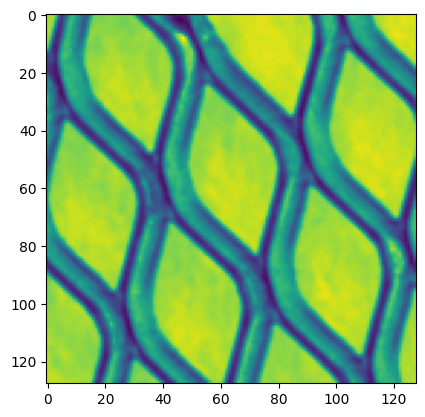

In [6]:
plt.imshow(patches_final[1][0][0])

In [7]:
#obsolute code
# class GridDatasetPatches(torch.utils.data.Dataset):
#     def __init__(self, dataset, transform=None):
#         self.dataset = dataset
#         self.transform = transform

#     def __len__(self):
#         return len(self.dataset)

#     def __getitem__(self, idx):
#         img = self.dataset[idx]
#         if self.transform:
#             img = self.transform(img)
#         return img



In [8]:
# # Can be used for troubleshooting dataloader
# images = torch.randn(100, 1, 512, 512)  # 100 grayscale images of size 128x128

# # Create the dataset
# patch_size = 128
# # dataset = GridDatasetPatches1(images, patch_size=patch_size)

# # Use DataLoader for parallel processing
# dataloader = torch.utils.data.DataLoader(patches_final, batch_size=64, shuffle=False, num_workers=1)

# # Iterate over the dataloader
# for batch_idx, patches in enumerate(dataloader):
#     print(f"Batch {batch_idx}: {patches.shape}")


In [9]:
# transform = transforms.Compose([
#             transforms.Resize((512, 512)),
#             transforms.Grayscale(),
#             transforms.ToTensor()
#         ])
# dataset_mv = ImageFolder('mvtec_ad/grid/train/', transform=transform)
# dataloader_mv = DataLoader(dataset_mv, batch_size= batch_size)
# dataset_mv.classes


In [10]:
# img = next(iter(dataloader_mv))
# print(img[0].shape)
# plt.imshow(img[0][0].squeeze())

## Declaring Parameters

In [11]:
workers = 20
image_size =128
nc =1
nz = 64  # Latent vector size
ngf = 64  # Generator feature maps
ndf = 64  # Discriminator feature maps
beta1 = 0.5  # Adam optimizer beta1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {torch.cuda.get_device_name(device)}")

Using device: NVIDIA L40


In [12]:
# Flatten patches into a single tensor
test_dataset = torch.cat([patches for patches in patches_final])

# Create DataLoader with optimized settings
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

# Print dataset and dataloader details for debugging
print(f"Test dataset size: {len(test_dataset)}")
# print(len(list(enumerate(test_dataloader))[0])[0].shape)
print(list(enumerate(test_dataloader))[-2][1].shape)


Test dataset size: 312
torch.Size([1, 1, 128, 128])


<class 'torch.Tensor'>


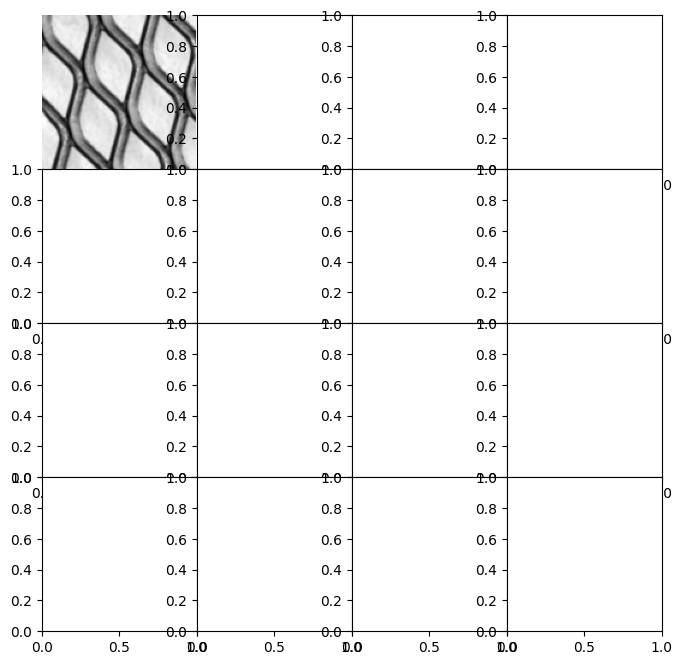

cuda


In [13]:
# Get a batch of images from the dataloader
data_iter = iter(test_dataloader)
images = next(data_iter).to(device)

# Plot 4 images in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
print(type(images))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i][0].cpu(), cmap='gray',)
        ax.axis('off')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()
print(device)
## This demosntrates the patches are transfered to gpu

In [14]:
# Calculate seed_size and seed
seed_size = int(image_size / 16)  # Downsampling factor
input_features = ngf * 8 * seed_size * seed_size  # Initial tensor size

print(f"Seed size: {seed_size}, Seed: {input_features}")


Seed size: 8, Seed: 32768


In [15]:
import torch
import torch.nn as nn

class Generator(nn.Module): #modify this; first layer is linear , and then reshape (check if batchnorm and relu were used after this layer)
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a linear layer
            nn.Linear(nz,input_features,bias=True),
            nn.Unflatten(1,(ngf*8,seed_size,seed_size)),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),
            # state size. ``(ngf*8) x 4 x 4``
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 5, 2, 2, 1, bias=True),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. ``(ngf*4) x 8 x 8``
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 5, 2, 2, 1, bias=True),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. ``(ngf*2) x 16 x 16``
            nn.ConvTranspose2d( ngf * 2, ngf, 5, 2, 2, 1, bias=True),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf,nc,5,2,2,1,bias=True),
            nn.Tanh()
            # state size. ``(nc) x 64 x 64``
        )

    def forward(self, input):
        return self.main(input)

# Create the generator
netG = Generator(1).to(device)

# Handle multi-GPU if available
# if (device.type == 'cuda') :
#     netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)

# Print the model architecture
print(netG)


Generator(
  (main): Sequential(
    (0): Linear(in_features=64, out_features=32768, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(512, 8, 8))
    (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): ConvTranspose2d(64, 1, kernel_size=(5,

Output shape: torch.Size([16, 1, 128, 128])
torch.Size([32, 1, 128, 128])


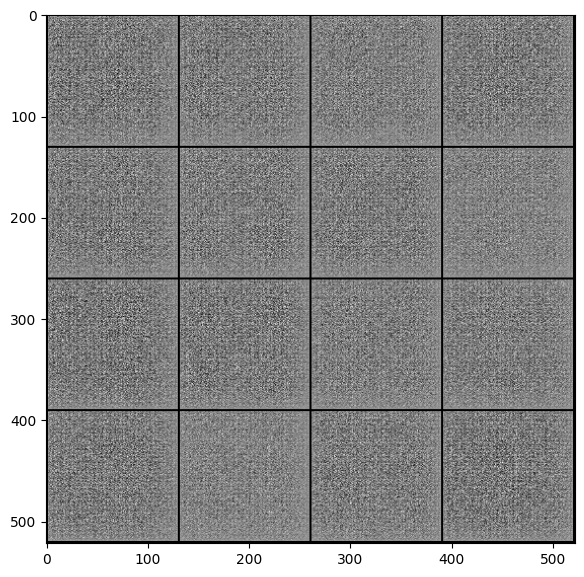

In [16]:
# Dummy input: Latent vector of size (batch_size, nz)
dummy_input = torch.randn(16, nz, device=device)  # Batch size = 16
output = netG(dummy_input)
print(f"Output shape: {output.shape}")  # Expected: (16, nc, image_size, image_size)

"""
Remove
"""

input=torch.randn(32,nz).to(device)

output=netG(input)
print(output.shape)
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)

# plt.imshow(input.cpu().detach().numpy(),cmap='gray')
plt.imshow(vutils.make_grid(output.cpu()[:16], nrow=4, normalize=True)[0], cmap = 'gray')
# plt.subplot(1,2,2)
# plt.imshow(np.transpose(vutils.make_grid(patch_ensemble.to(device),nrow=4, padding=3, normalize=True).cpu()))


Generator done.
Try after loadeing



In [17]:
netG.load_state_dict(torch.load('/home/cudaq/files/gen_rand_rotation.pth',map_location=torch.device(device)))


/tmp/ipykernel_155481/4153249719.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('/home/cudaq/files/gen_rand_rotation.pth',map_location=t

<All keys matched successfully>

In [18]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is ``(nc) x 64 x 64``
            nn.Conv2d(nc, ndf, 5, 2, 2, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``
            nn.Conv2d(ndf, ndf * 2, 5, 2, 2, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``
            nn.Conv2d(ndf * 2, ndf * 4, 5, 2, 2, bias=True),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``
            nn.Conv2d(ndf * 4, ndf * 8, 5, 2, 2, bias=True),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``
            nn.Flatten(start_dim=1),
            nn.Linear(ndf*8*seed_size*seed_size,1,bias=True),
            #nn.Conv2d(ndf * 8, 1, 5, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)
# Create the Discriminator
netD = Discriminator(1).to(device)


# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
# netD.apply(weights_init)

# Print the model
# print(netD)
# netD(test_dataloader)

In [19]:
netD.load_state_dict(torch.load('/home/cudaq/files/dis_rand_rotation.pth',map_location=torch.device(device)))


/tmp/ipykernel_155481/1768255094.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netD.load_state_dict(torch.load('/home/cudaq/files/dis_rand_rotation.pth',map_location=t

<All keys matched successfully>

In [20]:
# import torchvision.models as models
# from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

# # Load a pre-trained model
# model = models.resnet50(pretrained=True)

# # Define which nodes to return
# return_nodes = {
#     'layer4.2.relu': 'relu_layer4',
#     'layer3.5.relu': 'relu_layer3'
# }

# # Create the feature extractor
# extractor = create_feature_extractor(model, return_nodes)

# # Prepare a sample input tensor (batch size = 1, channels = 3, height = 224, width = 224)
# input_tensor = torch.rand(1, 3, 224, 224)

# # Use the extractor to obtain features
# features = extractor(input_tensor)
# print(features['relu_layer3'].shape)

In [21]:
# model

In [22]:
# get_graph_node_names(model)

In [23]:
from torchvision.models.feature_extraction import create_feature_extractor
import torch
import torch.nn as nn
import numpy as np
from cudaq  import spin
# Extract intermediate layers
return_layers = {'main.10': 'output_layer'}

# L1 error function
def l1_error(x, y):
    assert x.shape == y.shape, f"Shape mismatch: {x.shape} vs {y.shape}"
    return torch.sum(torch.abs(x - y), dim=(-1, -2, -3))

# L2 error function
def l2_error(x, y):
    assert x.shape == y.shape, f"Shape mismatch: {x.shape} vs {y.shape}"
    # product = x[0].numel()
    return torch.mean((x - y) ** 2, dim=(-1, -2, -3)) # * product

# Quantum parameters
num_qubits = int(np.log2(nz))
num_an_qubits = 1
# num_qubits += num_an_qubits  # Include ancillary qubits if needed
# shift = torch.tensor(torch.pi / 2, device= device)
depth = 6


In [24]:
## SELECT FINITE DIFFERENCE AS GRADIENT FINDING METHOD
import pennylane as qml
dev = qml.device('default.qubit', wires =num_qubits)
@qml.qnode(device=dev, interface='torch', diff_method="parameter-shift")
def circuit(w):
    noise = torch.randn(num_qubits) * np.pi /2
    weights = w.reshape(depth, 3, num_qubits)
    for i in range(num_qubits):
        qml.RY(noise[i], wires =i)

    for depth_no in range(depth):
        for params in range(3):
            for i in range(num_qubits):
                if params == 0:
                    qml.RX(weights[depth_no][params][i], wires=i) 
                elif params == 1:
                    qml.RZ(weights[depth_no][params][i], wires=i)
                elif params == 2:
                    qml.CRX(weights[depth_no][params][i], wires=[i, i+1 if i < num_qubits -1 else 0])
    output = qml.probs(wires=list(range(num_qubits)))
    return output

weight = torch.randn(depth * num_qubits * 3)
noise = torch.randn(batch_size, num_qubits)
# print(qml.draw_mpl(circuit)(weight))
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.batch_size = batch_size
        self.num_params = num_qubits * 3 * depth
        self.params = nn.Parameter(torch.randn(batch_size, self.num_params , device=device)* 2*np.pi - np.pi )
        
    
    def forward(self):
        lst = torch.zeros(batch_size, 2**num_qubits)
        for batch in range(self.batch_size):
            x = circuit(self.params[batch])
            lst[batch] = (x / x.max() -0.5)*2
        # print(lst.shape)
        return lst

In [25]:
class Encoding_NN(nn.Module):
    def __init__(self):
        super(Encoding_NN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), 
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 64),
            nn.Tanh()
            
        )
    def forward(self):
        noise = torch.randn(batch_size, 7, device = device)
        return self.model(noise)
r=0

In [92]:
import time
from torchvision.utils import save_image

print("Testing phase started...")
num_test_iters = 500

netG.eval()
netD.eval()
array = []
losses = []
in_time = time.time()
lr = 0.01
l2_error = nn.MSELoss()
mid_out = IntermediateLayerGetter(netD, return_layers=return_layers, keep_output=True)
for batch_idx, x in enumerate(test_dataloader):
    test_loss = None
    anomaly_score = None
    f_G_z = None
    f_x = None
    if batch_idx <18:
        continue
    # Instantiate the encoder once per batch, not per iteration
    # encoder = Encoder().to(device)  # One encoder for every batch
    encoder = Encoding_NN().to(device)
    optimiser_encoder = torch.optim.Adam(encoder.parameters(), lr=0.01)

    # Move input to the device once
    x = x.to(device)
    for iter in range(num_test_iters):
        latent = torch.randn(batch_size, num_qubits).to(device)
        optimiser_encoder.zero_grad()

        # Forward pass through the encoder
        latent = encoder().view(batch_size, 64).to(device)
        # if iter ==num_test_iters-1: print(latent)
        # print("enocder output: ", latent_z)
        generated_images = netG(latent)
        
        # Compute the residual loss
        residual_loss = l2_error(x, generated_images)

        # residual_loss.backward()
        # # Get the intermediate outputs from the discriminator
        f_G_z, model_output = mid_out(generated_images)
        f_x, model_output_1 = mid_out(x)

        f_G_z = f_G_z['output_layer']
        f_x = f_x['output_layer']

        # # Compute the discriminator loss
        discriminator_loss = l2_error(f_G_z, f_x)

        # # Compute total test loss
        alpha = 0.1
        test_loss = alpha * discriminator_loss + (1 - alpha) * residual_loss
        # print(test_loss)
        test_loss.backward()
        losses.append(test_loss.item())
        # Update the encoder
        optimiser_encoder.step()
        # if iter%5==0 and iter > 0: print(iter,": done")
    # print(f'Batch {batch_idx} finished.')
    r+=1
    # Save generated images after processing the batch
    # save_image(torchvision.utils.make_grid(list(zip(x, generated_images))), f"images/batch{batch_idx}.png")
    # save_image(x, f'images/qgan/input_image{batch_idx}.png', normalize = True)
    # save_image(generated_images, f'images/qgan/batch_{batch_idx}_{r}.png', normalize=True)
    # plot_comp(x, generated_images)
    batch_time = time.time()
    print(f"Batch {batch_idx}, Time taken: {time.time() - in_time}")
    if batch_idx ==20: break

out_time = time.time()
print(f"Time taken in minutes: {(out_time - in_time) / 60}")


Testing phase started...
Batch 18, Time taken: 3.4870529174804688
Batch 19, Time taken: 5.209703683853149
Batch 20, Time taken: 7.076026439666748
Time taken in minutes: 0.11905797719955444


In [93]:
import cv2

114.0 [[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]]
461516


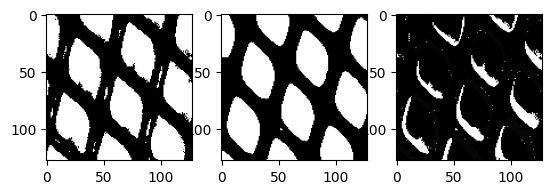

In [94]:
x_cpu = (255 * x.cpu().numpy().squeeze()).astype(np.uint8) 
generated_cpu = (255 * generated_images[0].cpu().detach().numpy().squeeze()).astype(np.uint8)
ret, otsu_thresholded_img = cv2.threshold(generated_cpu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(ret, otsu_thresholded_img)
t2 = 130
generated_cpu[generated_cpu>t2]=250
generated_cpu[generated_cpu<t2]=0
# print(x_cpu.max())
t1= 125
x_cpu[x_cpu>t1]=250
x_cpu[x_cpu<t1]=0
diff = (x_cpu - generated_cpu)
print(diff.sum())
diff[diff<0.0001]=0
plt.Figure(figsize=(2,8))
plt.subplot(1, 3, 2)
plt.imshow(x_cpu, cmap='gray')
plt.subplot(1, 3, 1)
plt.imshow(generated_cpu, cmap ='gray')
plt.subplot(1, 3, 3)
# print(torch.nn.functional.normalize(generated_images.detach())*255)
plt.imshow(diff, cmap='gray')
plt.show()

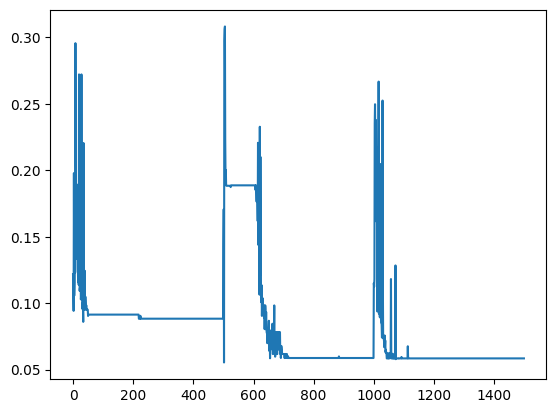

In [95]:
plt.plot(np.arange(len(losses)), losses)


Sum of differences (after thresholding): 461516


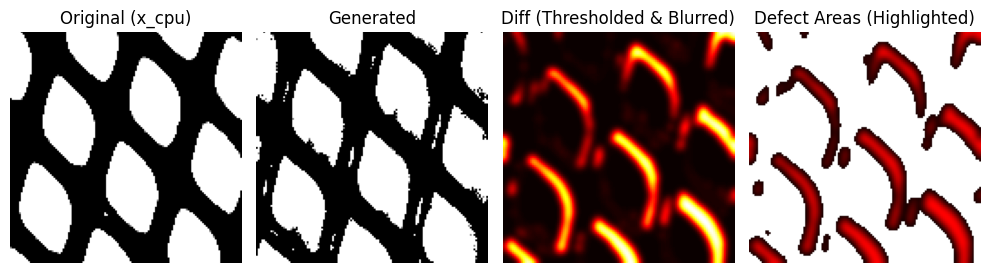


Original torch.nn.functional.normalize output (scaled to 0-255):
tensor([[202.7080, 208.8924, 192.7415,  ..., 202.0959, 202.5506, 202.8352],
        [207.6263, 206.4383, 202.7272,  ..., 186.2913, 198.3473, 200.7085],
        [199.3079, 212.7600, 198.3807,  ..., 197.7185, 197.3379, 204.8488],
        ...,
        [194.7910, 233.8966, 241.0773,  ...,  70.9268,  94.8033,  71.7015],
        [215.0621, 230.6523, 241.6179,  ...,  77.9756,  87.5216,  98.5428],
        [209.4688, 233.1082, 245.0258,  ...,  86.2154,  99.3417,  81.9697]],
       device='cuda:0')


In [96]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
from PIL import Image, ImageFilter # For applying blur and potential alignment if needed

# Assuming x and generated_images are already defined PyTorch tensors
# For demonstration purposes, let's create some dummy data
# x = torch.randn(1, 1, 64, 64) * 0.5 + 0.5 # Example original image (normalized to 0-1)
# generated_images = torch.randn(1, 1, 64, 64) * 0.5 + 0.5 # Example generated image

# Ensure generated_images has the correct shape for processing if it's a batch
if generated_images.dim() == 4:
    # Assuming batch_size, channels, height, width
    generated_image_single = generated_images[0] # Take the first image from the batch
elif generated_images.dim() == 3:
    # Assuming channels, height, width or height, width, channels
    generated_image_single = generated_images
else:
    raise ValueError("generated_images has an unexpected number of dimensions.")

# Convert tensors to CPU and NumPy arrays, squeeze to remove singleton dimensions
# x_cpu = x.cpu().numpy().squeeze()
# generated_cpu = generated_image_single.cpu().detach().numpy().squeeze()

# Calculate the absolute difference
diff = np.abs(x_cpu - generated_cpu)

# Thresholding the difference to highlight significant differences
# This is already in your code, keeping it
diff[diff < 0.0001] = 0

print(f"Sum of differences (after thresholding): {diff.sum()}")

# --- Apply Blur ---
# Convert NumPy arrays back to PIL Images for easy blurring
x_pil = Image.fromarray((x_cpu * 255).astype(np.uint8))
generated_pil = Image.fromarray((generated_cpu * 255).astype(np.uint8))
diff_pil = Image.fromarray((diff * 255).astype(np.uint8))

# Apply Gaussian blur
blur_radius = 2 # Adjust this value as needed
x_blurred = x_pil.filter(ImageFilter.GaussianBlur(blur_radius))
generated_blurred = generated_pil.filter(ImageFilter.GaussianBlur(blur_radius))
diff_blurred = diff_pil.filter(ImageFilter.GaussianBlur(blur_radius))

# Convert back to NumPy for plotting
x_blurred_np = np.array(x_blurred) / 255.0 # Normalize back to 0-1
generated_blurred_np = np.array(generated_blurred) / 255.0
diff_blurred_np = np.array(diff_blurred) / 255.0

# --- Normalization for visualization ---
# The images are typically already normalized to 0-1 if they are outputs of a network.
# For visualization, especially of the 'diff', you might want to normalize it
# to span the full 0-1 range if the differences are very small, to make them visible.
# However, for showing defect areas, just clamping to 0-1 or using a specific colormap might be better.
# Let's normalize the 'diff' for better contrast if it's very sparse.
# If you want to highlight small differences, you might scale 'diff_blurred_np'
# For example, if max diff is small, scale it up:
if diff_blurred_np.max() > 0:
    diff_normalized_for_display = diff_blurred_np / diff_blurred_np.max()
else:
    diff_normalized_for_display = diff_blurred_np # Avoid division by zero


# --- Alignment (Conceptual) ---
# Image alignment is a complex topic and usually involves techniques like
# phase correlation, feature matching (SIFT, SURF), or optical flow.
# If your images are already pre-aligned (e.g., from a dataset where
# the generator is trained on aligned data), you might not need explicit alignment here.
# If there's a slight translation/rotation, libraries like OpenCV would be used.
# For this example, we'll assume they are reasonably aligned.
# If misalignment is an issue, you'd need to pre-process 'x' and 'generated_images'
# before calculating 'diff'.

# --- Plotting ---
plt.figure(figsize=(10, 5)) # Adjusted figure size for better readability

# Original Image
plt.subplot(1, 4, 1)
plt.imshow(x_cpu, cmap='gray')
plt.title('Original (x_cpu)')
plt.axis('off')

# Generated Image
plt.subplot(1, 4, 2)
plt.imshow(generated_cpu, cmap='gray')
plt.title('Generated')
plt.axis('off')

# Absolute Difference (Thresholded and Blurred)
plt.subplot(1, 4, 3)
# Using a colormap like 'hot' or 'jet' can make defect areas stand out more
# in the difference image compared to 'gray'.
plt.imshow(diff_normalized_for_display, cmap='hot')
plt.title('Diff (Thresholded & Blurred)')
plt.axis('off')

# Highlighted Defect Area (e.g., thresholded difference overlaid or just the difference)
# This subplot will specifically focus on the defect areas.
plt.subplot(1, 4, 4)
# You could apply another threshold or just display the normalized difference again
# but perhaps with a slightly different colormap or enhanced contrast for defects.
# For instance, if you want to show only areas above a certain difference:
defect_mask = diff_blurred_np > (diff_blurred_np.max() * 0.1) # Example threshold for defects
# Create an RGBA image where defects are red, and non-defects are transparent or black
defect_highlight_image = np.zeros((*x_cpu.shape, 4)) # RGBA
defect_highlight_image[..., 0] = diff_normalized_for_display # Red channel based on diff
defect_highlight_image[..., 3] = defect_mask * 1.0 # Alpha channel for transparency
plt.imshow(defect_highlight_image)
plt.title('Defect Areas (Highlighted)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Your original print statement for torch.nn.functional.normalize(generated_images.detach())*255
# This line doesn't directly relate to the plotting block above but is a separate operation.
# It seems you want to normalize the generated_images and scale them to 0-255.
# This would be useful if you're trying to view pixel values or prepare for saving as an image.
# It's important to note that `torch.nn.functional.normalize` typically normalizes
# along a dimension (e.g., L2 normalization of features). If you want to scale
# pixel values to 0-255 based on min/max, it's a different kind of normalization.

print("\nOriginal torch.nn.functional.normalize output (scaled to 0-255):")
# Assuming generated_images is a single image or you want to process the first one
# If generated_images is batch, channel, height, width:
if generated_images.dim() == 4:
    # Normalize each image in the batch independently (example)
    normalized_gen_images = []
    for i in range(generated_images.shape[0]):
        # Normalize between min and max pixel values of each image and then scale to 0-255
        img = generated_images[i].detach()
        min_val = img.min()
        max_val = img.max()
        if max_val - min_val > 0:
            normalized_img = (img - min_val) / (max_val - min_val) * 255
        else:
            normalized_img = img * 255 # If all pixels are same value
        normalized_gen_images.append(normalized_img)
    # Stack them back if needed, or just print the first one
    print(normalized_gen_images[0].squeeze()) # Print the first normalized image
else:
    # If it's a single image (e.g., C, H, W)
    img = generated_images.detach()
    min_val = img.min()
    max_val = img.max()
    if max_val - min_val > 0:
        normalized_img = (img - min_val) / (max_val - min_val) * 255
    else:
        normalized_img = img * 255
    print(normalized_img.squeeze())

Detected translation: dx=-0.25, dy=-0.43
Sum of differences after alignment and blur: 1795.59619140625


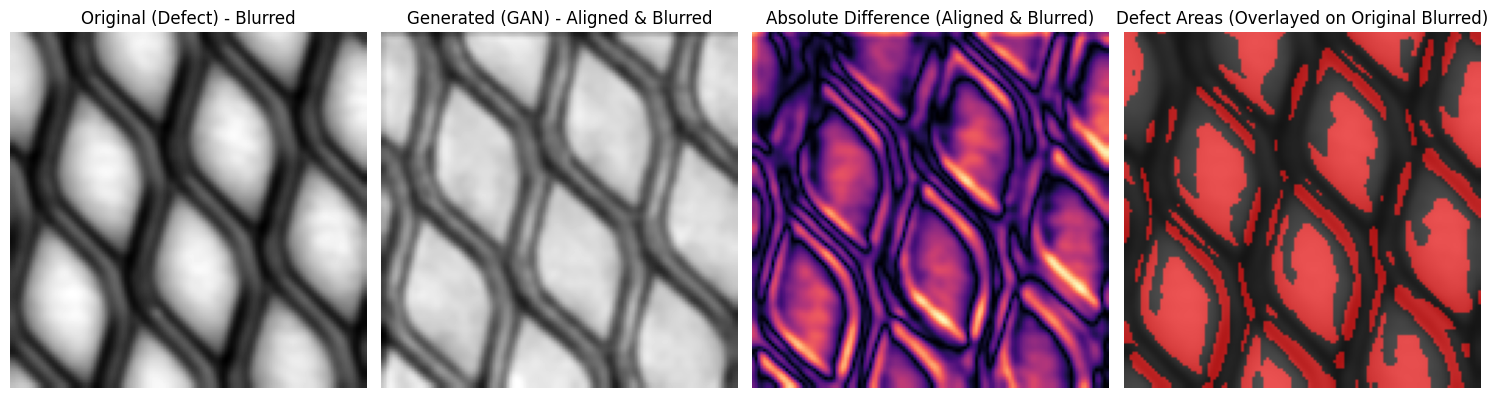

In [97]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image # Still useful for consistent image type handling if needed, but we'll stick to OpenCV for blurring

# Assuming x and generated_images are already defined PyTorch tensors
# For demonstration purposes, let's create some dummy grayscale data
# Ensure tensors are (batch_size, channels, height, width) with channels = 1 for grayscale
# Let's simulate a slight translation in generated_images
# original_image_np = (torch.randn(64, 64) * 0.2 + 0.5).clamp(0, 1).numpy() # Base image
# # Create a slightly shifted version for the 'generated' image
# generated_image_np = np.roll(original_image_np, shift=(5, -3), axis=(0, 1)) # Shifted by (5 down, 3 left)
# generated_image_np += (torch.randn(64, 64) * 0.1).numpy() # Add some noise for realism
# generated_image_np = np.clip(generated_image_np, 0, 1) # Ensure values are within [0, 1]

# x = torch.from_numpy(original_image_np).unsqueeze(0).unsqueeze(0) # Add batch and channel dims
# generated_images = torch.from_numpy(generated_image_np).unsqueeze(0).unsqueeze(0)


# --- 1. Convert tensors to NumPy arrays (if not already) and squeeze ---
# Make sure they are float32 for OpenCV processing
x_cpu = x.cpu().numpy().squeeze().astype(np.float32)
generated_cpu = generated_images[0].cpu().detach().numpy().squeeze().astype(np.float32)

# Ensure both images are the same size
if x_cpu.shape != generated_cpu.shape:
    print("Warning: Images have different sizes. Resizing generated_cpu to match x_cpu.")
    generated_cpu = cv2.resize(generated_cpu, (x_cpu.shape[1], x_cpu.shape[0]))


# --- 2. Align Translation using Phase Correlation ---
# cv2.phaseCorrelate works best on grayscale images. Input should be float32.
# It returns the (dx, dy) shift where dx is horizontal, dy is vertical.
# It also returns the response, which indicates the quality of the correlation peak.
shift, response = cv2.phaseCorrelate(x_cpu, generated_cpu)
dx, dy = shift[0], shift[1] # dx is horizontal (cols), dy is vertical (rows)

print(f"Detected translation: dx={dx:.2f}, dy={dy:.2f}")

# Create the translation matrix M
# M = [[1, 0, dx], [0, 1, dy]]
# Note: OpenCV's warpAffine expects (width, height) for size, and dx for columns, dy for rows.
# To shift 'generated_cpu' to align with 'x_cpu', you apply the negative of the detected shift
M = np.float32([[1, 0, -dx], [0, 1, -dy]])

# Apply the translation to the generated image
# cv2.warpAffine(src, M, dsize, flags, borderMode, borderValue)
# dsize is (width, height) -> (cols, rows)
aligned_generated_cpu = cv2.warpAffine(generated_cpu, M, (x_cpu.shape[1], x_cpu.shape[0]),
                                       flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)


# --- 3. Apply Blur to both aligned_generated_cpu and x_cpu ---
blur_kernel_size = (5, 5) # Needs to be an odd positive integer tuple
sigma_x = 0 # If 0, it's calculated from kernel size

x_blurred = cv2.GaussianBlur(x_cpu, blur_kernel_size, sigma_x)
aligned_generated_blurred = cv2.GaussianBlur(aligned_generated_cpu, blur_kernel_size, sigma_x)


# --- 4. Calculate Difference (Optional, but good for defect visualization) ---
diff = np.abs(x_blurred - aligned_generated_blurred)
diff[diff < 0.0001] = 0 # Threshold small differences to zero

print(f"Sum of differences after alignment and blur: {diff.sum()}")

# Normalize the difference for better visualization if values are small
if diff.max() > 0:
    diff_normalized_for_display = diff / diff.max()
else:
    diff_normalized_for_display = diff


# --- 5. Plotting for comparison ---
plt.figure(figsize=(15, 6))

# Original Image (Defect) - Blurred
plt.subplot(1, 4, 1)
plt.imshow(x_blurred, cmap='gray')
plt.title('Original (Defect) - Blurred')
plt.axis('off')

# Generated Image (GAN Output) - Blurred and Aligned
plt.subplot(1, 4, 2)
plt.imshow(aligned_generated_blurred, cmap='gray')
plt.title('Generated (GAN) - Aligned & Blurred')
plt.axis('off')

# Absolute Difference (Blurred and Normalized)
plt.subplot(1, 4, 3)
plt.imshow(diff_normalized_for_display, cmap='magma') # Use a perceptual colormap
plt.title('Absolute Difference (Aligned & Blurred)')
plt.axis('off')

# Highlighted Defect Areas (Overlayed) - Similar to previous example
plt.subplot(1, 4, 4)
# Convert original blurred image to RGB for overlay
x_blurred_rgb = plt.cm.gray(x_blurred)[:,:,:3]

defect_threshold = 0.35 # Adjust this threshold (0 to 1) to define "defect"
significant_diff_mask = diff_normalized_for_display > defect_threshold

defect_overlay_color = np.zeros_like(x_blurred_rgb)
defect_overlay_color[significant_diff_mask] = [1, 0, 0] # Red color for defects

alpha = 0.6 # Transparency of the overlay
combined_image = x_blurred_rgb * (1 - alpha) + defect_overlay_color * alpha

plt.imshow(combined_image)
plt.title('Defect Areas (Overlayed on Original Blurred)')
plt.axis('off')

plt.tight_layout()
plt.show()

# You can also display the non-blurred versions for comparison if you want
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(x_cpu, cmap='gray')
# plt.title('Original (Raw)')
# plt.axis('off')
# plt.subplot(1, 2, 2)
# plt.imshow(aligned_generated_cpu, cmap='gray')
# plt.title('Generated (Aligned Raw)')
# plt.axis('off')
# plt.show()

In [91]:
# # import torch
# # import numpy as np
# # import cudaq
# # from cudaq import spin
# # from cudaq.gradients import ParameterShift
# import cudaq.runtime
# import cudaq.runtime.observe


# cudaq.set_target('nvidia')
# cudaq.get_target().name

In [22]:
# @cudaq.kernel
# def ansatz(qubit_count: int, x: list[float], thetas: list[float]):
#     qubits = cudaq.qvector(qubit_count)
#     for i in range(qubit_count):
#         ry(x[i], qubits[i])
#     depth = 4
#     for d_num in range(depth):
#         for j in range(3):
#             number=(d_num*qubit_count*3)+(j*qubit_count)
#             if (j==0):
#                 for qubit in range(qubit_count):
#                     rx(thetas[number+qubit],qubits[qubit])

#             if(j==1):
#                 for qubit in range(qubit_count):
#                     rz(thetas[number+qubit],qubits[qubit])

#             if(j==2):
#                 for qubit in range(qubit_count):
#                     rx.ctrl(thetas[number+qubit],qubits[qubit],qubits[((qubit+1)%qubit_count)])
#     for i in range(qubit_count):
#         mx(qubits[i])

In [8]:
# print(cudaq.draw(ansatz, 6))

     ╭───╮                         
q0 : ┤ h ├──●──────────────────────
     ╰───╯╭─┴─╮                    
q1 : ─────┤ x ├──●─────────────────
          ╰───╯╭─┴─╮               
q2 : ──────────┤ x ├──●────────────
               ╰───╯╭─┴─╮          
q3 : ───────────────┤ x ├──●───────
                    ╰───╯╭─┴─╮     
q4 : ────────────────────┤ x ├──●──
                         ╰───╯╭─┴─╮
q5 : ─────────────────────────┤ x ├
                              ╰───╯



In [3]:
# # import cudaq


# # # Define our kernel.
# @cudaq.kernel
# def ansatz(qubit_count: int):
#     # Allocate our qubits.
#     qvector = cudaq.qvector(qubit_count)
#     # Place the first qubit in the superposition state.
#     h(qvector[0])
#     # Loop through the allocated qubits and apply controlled-X,
#     # or CNOT, operations between them.
#     for qubit in range(qubit_count - 1):
#         x.ctrl(qvector[qubit], qvector[qubit + 1])
#     # Measure the qubits.
#     mz(qvector)

In [ ]:
# import sys
# import timeit

# # Will time the execution of our sample call.
# code_to_time = 'cudaq.sample(ansatz, qubit_count, shots_count=1000000)'
# qubit_count = 20
# x = [i/6 for i in range(qubit_count)]
# theta = [x/6 for x in range(qubit_count)]*4

# # Execute on CPU backend.
# cudaq.set_target('qpp-cpu')
# print('CPU time')  # Example: 27.57462 s.
# print(timeit.timeit(stmt=code_to_time, globals=globals(), number=1))

# if cudaq.num_available_gpus() > 0:
#     # Execute on GPU backend.
#     cudaq.set_target('nvidia')
#     print('GPU time')  # Example: 0.773286 s.
#     print(timeit.timeit(stmt=code_to_time, globals=globals(), number=1))

CPU time
0.9130858529824764
GPU time
0.5376668209792115


In [68]:


# # Define the quantum circuit as a CUDA Quantum kernel
# @cudaq.kernel
# def ansatz(qubit_count: int, x: list[float], theta: list[float]):
#     qubits = cudaq.qvector(qubit_count)
    
#     # Data encoding layer
#     for i in range(qubit_count):
#         cudaq.ry(x[i], qubits[i])

#     # Trainable layers
#     depth = len(theta) // (3 * qubit_count)
#     for d in range(depth):
#         offset = d * 3 * qubit_count
#         # RX Layer
#         for i in range(qubit_count):
#             cudaq.rx(theta[offset + i], qubits[i])
#         # RZ Layer
#         for i in range(qubit_count):
#             cudaq.rz(theta[offset + qubit_count + i], qubits[i])
#         # Entanglement layer
#         for i in range(qubit_count):
#             control = qubits[i]
#             target = qubits[(i + 1) % qubit_count]
#             cudaq.rx.ctrl(0.0, control, target)

# # Define Hamiltonian observable (e.g., Z on all qubits)
# hamiltonian = spin.z(0)
# for i in range(1, 6):  # Adjust based on number of qubits
#     hamiltonian += spin.z(i)

# # Gradient strategy
# gradient_strategy = ParameterShift(ansatz, hamiltonian, -1)

# # Custom Torch Function
# class QuantumFunction(torch.autograd.Function):
#     @staticmethod
#     def forward(ctx, x: torch.Tensor, thetas: torch.Tensor, qubit_count: int):
#         """
#         Forward pass: evaluates the quantum circuit and returns expectation values.
        
#         Args:
#           x: Input tensor [batch_size, n_features]
#           thetas: Trainable parameters [n_parameters]
#           qubit_count: Number of qubits
#         Returns:
#           Expectation values [batch_size, 1]
#         """
#         ctx.qubit_count = qubit_count
#         ctx.save_for_backward(x, thetas)
#         ctx.gradient_strategy = gradient_strategy

#         batch_size = x.shape[0]
#         results = []

#         # Evaluate expectation value for each input in batch
#         for xi in x:
#             expectation = cudaq.observe(ansatz, hamiltonian, qubit_count, xi.tolist(), thetas.tolist()).expectation()
#             results.append(expectation)

#         return torch.tensor(results, device=x.device).unsqueeze(-1)

#     @staticmethod
#     def backward(ctx, grad_output: torch.Tensor):
#         """
#         Backward pass: computes gradients using parameter-shift rule.
#         """
#         x, thetas = ctx.saved_tensors
#         batch_size = x.shape[0]
#         n_params = thetas.shape[0]
#         gradients_theta = torch.zeros((batch_size, n_params), device=x.device)

#         # Use built-in gradient strategy to compute gradients
#         for i, xi in enumerate(x):
#             grad_i = ctx.gradient_strategy.evaluate(xi.tolist(), thetas.tolist())
#             gradients_theta[i] = torch.tensor(grad_i, device=x.device)

#         # Chain rule: grad_output is [batch_size, 1], gradients_theta [batch_size, n_params]
#         grad_theta = torch.sum(grad_output * gradients_theta, dim=0)
#         grad_x = torch.zeros_like(x)  # Gradients w.r.t inputs not supported here yet

#         return grad_x, grad_theta, None

NameError: name 'ParameterShift' is not defined

In [65]:
# from cudaq import spin
# def hea_circuit(qubit_count: int,x: np.ndarray, thetas: np.ndarray):
#             qubits = cudaq.qvector(qubit_count)
#             for i in range(qubit_count):
#                 ry(x[i], qubits[i])
#             for d_num in range(depth):
#                for j in range(3):
#                  number=(d_num*qubit_count*3)+(j*qubit_count)
#                  if (j==0):
#                    for qubit in range(qubit_count):
#                       rx(thetas[number+qubit],qubits[qubit])

#                  if(j==1):
#                    for qubit in range(qubit_count):
#                      rz(thetas[number+qubit],qubits[qubit])

#                  if(j==2):
#                    for qubit in range(qubit_count):
#                      rx.ctrl(thetas[number+qubit],qubits[qubit],qubits[((qubit+1)%qubit_count)])
#             for i in range(qubit_count):
#              mx(qubits[i])
# class QuantumFunction(Function):
#     """
#     Encapsulates a parameterized quantum circuit with analytic gradients
#     via parameter-shift rule.
#     """

#     @staticmethod
#     def forward(ctx, x, thetas, qubit_count):
#         """
#         Forward pass: evaluate expectation value of Z_0
#         """
#         ctx.save_for_backward(x, thetas)
#         ctx.qubit_count = qubit_count
#         batch_size = x.shape[0]

#         results = []
#         for i in range(batch_size):
#             xi = x[i].cpu().detach().numpy().astype(np.float64)
#             theta_i = thetas.cpu().detach().numpy().astype(np.float64)
#             hamiltonian = spin.z(0)
#             energy = cudaq.observe(hea_circuit, hamiltonian, qubit_count, xi, theta_i).expectation()
#             results.append([energy])

#         return torch.tensor(results, device=device, dtype=torch.float32)

#     @staticmethod
#     def backward(ctx, grad_output):
#         """
#         Backward pass: compute gradients using parameter-shift rule
#         """
#         x, thetas = ctx.saved_tensors
#         qubit_count = ctx.qubit_count
#         shift = np.pi / 2
#         num_parameters = thetas.shape[0]
#         batch_size = x.shape[0]

#         grad_theta = torch.zeros_like(thetas, device=device)
#         grad_input = torch.zeros_like(x, device=device)

#         # For each parameter
#         for p_idx in range(num_parameters):
#             thetas_plus = thetas.clone()
#             thetas_minus = thetas.clone()

#             thetas_plus[p_idx] += shift
#             thetas_minus[p_idx] -= shift

#             results_plus = []
#             results_minus = []

#             for i in range(batch_size):
#                 xi = x[i].cpu().numpy().astype(np.float64)

#                 theta_p = thetas_plus.cpu().numpy().astype(np.float64)
#                 theta_m = thetas_minus.cpu().numpy().astype(np.float64)

#                 res_p = cudaq.observe(hea_circuit, spin.z(0), qubit_count, xi, theta_p).expectation()
#                 res_m = cudaq.observe(hea_circuit, spin.z(0), qubit_count, xi, theta_m).expectation()

#                 results_plus.append(res_p)
#                 results_minus.append(res_m)

#             results_plus = torch.tensor(results_plus, device=device, dtype=torch.float32).unsqueeze(-1)
#             results_minus = torch.tensor(results_minus, device=device, dtype=torch.float32).unsqueeze(-1)

#             grad = (results_plus - results_minus) / 2.0
#             grad_theta[p_idx] = (grad_output.unsqueeze(-1) * grad).sum()

#         # Optional: Compute gradient w.r.t. inputs using finite difference or another method
#         # For now, we'll skip it unless needed
#         return grad_input, grad_theta, None

In [58]:
# class QuantumLayer(nn.Module):
#     """Encapsulates a quantum circuit into a quantum layer adhering to PyTorch convention"""

#     def __init__(self, qubit_count, an_qubit_count, shift):
#         super(QuantumLayer, self).__init__()
#         self.quantum_circuit = QuantumFunction(qubit_count, an_qubit_count, depth)
#         self.shift = shift

#     def forward(self, input, thetas):
#         # Ensure tensors are on the correct device
#         input = input.to(device)
#         thetas = thetas.to(device)
        
#         result = QuantumFunction.apply(input, thetas, self.quantum_circuit, self.shift)
#         return result


# class Encoder(nn.Module):
#     def __init__(self, ngpu, qubit_count, an_qubit_count, shift):
#         super(Encoder, self).__init__()
#         self.ngpu = ngpu
#         self.thetas = nn.Parameter(torch.randn(qubit_count * depth * 3, device=device))
#         self.quantum_circuit = QuantumLayer(qubit_count, an_qubit_count, shift)

#     def forward(self, input):
#         # Ensure input is on the correct device
#         input = input.to(device)
#         result = self.quantum_circuit(input, self.thetas)
#         return result


In [57]:
class QuantumFunction(Function):
    """Allows the quantum circuit to input data, output expectation values
    and calculate gradients of variational parameters via finite difference"""

    def __init__(self, qubit_count: int,an_qubit_count:int,depth: int):
        """Define the quantum circuit in CUDA Quantum"""

        @cudaq.kernel
        def kernel(qubit_count: int,x: np.ndarray, thetas: np.ndarray):
            qubits = cudaq.qvector(qubit_count)
            for i in range(qubit_count):
                ry(x[i], qubits[i])
            for d_num in range(depth):
               for j in range(3):
                 number=(d_num*qubit_count*3)+(j*qubit_count)
                 if (j==0):
                   for qubit in range(qubit_count):
                      rx(thetas[number+qubit],qubits[qubit])

                 if(j==1):
                   for qubit in range(qubit_count):
                     rz(thetas[number+qubit],qubits[qubit])

                 if(j==2):
                   for qubit in range(qubit_count):
                     rx.ctrl(thetas[number+qubit],qubits[qubit],qubits[((qubit+1)%qubit_count)])
            for i in range(qubit_count):
             mx(qubits[i])
            # cudaq.draw(qubits)
        self.kernel = kernel
        self.qubit_count = qubit_count
        self.an_qubit_count = an_qubit_count

    def run(self, x, theta_vals_list):
      qubit_count = [self.qubit_count for _ in range(theta_vals_list.shape[0])]

      results = cudaq.sample(self.kernel, qubit_count, x, theta_vals_list)
      results_final = []
      bitstrings = [f"{i:06b}" for i in range(nz)]

      for item in results:
          item_1 = {}
          for k, v in item.items():
              final_v = float(v) / sum(item.values())
              item_1[k] = final_v
          for bitstring in bitstrings:
              if bitstring not in item_1:
                  item_1[bitstring] = 0

          item_values = list(item_1.values())
          # Scale from 0–1 to -1 to 1
          item_values = [2 * (v - min(item_values)) / (max(item_values) - min(item_values)) - 1 for v in item_values]
          item_values = item_values[:nz]  # Truncate if needed

          results_final.append(item_values)


      results_final = [torch.tensor(list1, device=device) for list1 in results_final]
      results_final = torch.stack(results_final, dim=0).to(device)
      return results_final

    @staticmethod
    def forward(ctx,x, thetas, quantum_circuit, shift):

        # Save shift and quantum_circuit in context to use in backward.
        ctx.shift = shift
        ctx.quantum_circuit = quantum_circuit
        theta_vals_list=[]
        for j in range(x.shape[0]):
          theta_vals_list.append(thetas)
        theta_vals_list=torch.stack(theta_vals_list,dim=0)
        results = ctx.quantum_circuit.run(x,theta_vals_list)
        # print("x shape: ", x.shape, "results shape: ", results.shape, theta_vals_list.shape)

        #print("forward results done")
        ctx.save_for_backward(x,theta_vals_list,results)
        return results



    
    
    @staticmethod
    def backward(ctx, grad_output):
        """
        Vectorized backward pass using parameter-shift rule.
        Computes gradients w.r.t. thetas only.
        """
        x, thetas, results = ctx.saved_tensors
        quantum_circuit = ctx.quantum_circuit
        shift = np.pi / 2
        batch_size, num_thetas = thetas.shape
        nz = results.shape[1]

        # Repeat input for all shifted parameters
        x_repeated = x.repeat_interleave(2, dim=0)  # (batch_size * 2, input_dim)

        # Create theta shifts for all parameters
        thetas_repeated = thetas.repeat_interleave(2, dim=0)  # (batch_size * 2, num_thetas)
        shift_tensor = torch.zeros_like(thetas_repeated)
        # print(shift_tensor.shape, num_thetas, nz)
        for i in range(num_thetas):
            shift_tensor[(i//2)*2, i] = shift
            shift_tensor[(i//2)*2 + 1, i] = -shift

        thetas_shifted = thetas_repeated + shift_tensor

        # Run once for all shifted parameters
        results_shifted = quantum_circuit.run(x_repeated, thetas_shifted)  # (batch_size * 2, nz)

        # Split into plus and minus
        results_plus = results_shifted[::2]   # (batch_size, nz)
        results_minus = results_shifted[1::2] # (batch_size, nz)

        # Compute Jacobian: (batch_size, nz, num_thetas)
        jacobian = (results_plus.unsqueeze(-1) - results_minus.unsqueeze(-1)) / 2.0
        jacobian = jacobian.expand(-1, -1, num_thetas)  # Make broadcasting explicit

        # Now apply chain rule using einsum
        final_grad = torch.einsum('bo,bop->bp', grad_output, jacobian)  # (batch_size, num_thetas)

        return None, final_grad, None, None  # No grads for x, circuit, shift

In [54]:
# import os
# import shutil

# if not os.path.exists('generated_images'):
#     os.mkdir('generated_images')

# for filename in os.listdir('.'):
#     if filename.startswith('generated_image_'):
#         shutil.move(filename, os.path.join('generated_images', filename))


In [55]:
# print(f"Shape of f_G_z: {f_G_z.shape}")
# print(f"Shape of f_x: {f_x.shape}")
# print(f"Shape of generated_images: {generated_images.shape}")


In [56]:
device

device(type='cuda')

In [123]:
print(encoder.thetas.shape)

torch.Size([126])


In [59]:
image = next(iter(test_dataloader)).to(device)

latent = torch.randn(batch_size, 6).to(device)
encoder = Encoder(1, qubit_count=num_qubits, an_qubit_count=num_an_qubits, shift=shift).to(device)  # One encoder for every batch
optimiser_encoder = torch.optim.Adam(encoder.parameters(), lr=0.001, betas=(beta1, 0.999))
latentz = encoder(latent)
print("latent shape:",latent.shape, latentz.shape)
generated_images = netG(latentz.float())

print("image shape:", image.shape)
print("Generated image shape: ", generated_images.shape)
        # Compute the residual loss
residual_loss = l2_error(image, generated_images)
print(residual_loss)
# plt.imshow(generated_images[0][0].cpu().detach().numpy())



latent shape: torch.Size([64, 6]) torch.Size([64, 64])
image shape: torch.Size([64, 1, 128, 128])
Generated image shape:  torch.Size([64, 1, 128, 128])
tensor([0.0408, 0.0434, 0.0645, 0.0379, 0.0523, 0.0620, 0.0374, 0.0550, 0.0529,
        0.0184, 0.0443, 0.0469, 0.0159, 0.0637, 0.1100, 0.0277, 0.0325, 0.0575,
        0.0696, 0.1057, 0.0591, 0.0877, 0.0720, 0.0973, 0.0665, 0.0484, 0.0676,
        0.0224, 0.0579, 0.0356, 0.0401, 0.0349, 0.0232, 0.0748, 0.0468, 0.0325,
        0.0458, 0.0701, 0.0683, 0.0420, 0.0612, 0.0665, 0.0624, 0.0649, 0.0779,
        0.0725, 0.0507, 0.0551, 0.0597, 0.0373, 0.0333, 0.0671, 0.0731, 0.0657,
        0.0371, 0.0184, 0.0673, 0.0661, 0.0437, 0.0333, 0.0273, 0.0320, 0.0604,
        0.0848], device='cuda:0', grad_fn=<MeanBackward1>)


In [25]:
mid_out = IntermediateLayerGetter(netD, return_layers=return_layers, keep_output=True)
f_G_z, model_output = mid_out(generated_images)
f_x, model_output_1 = mid_out(image)
print(f_G_z.keys(), f_G_z['intermediate_layer_10'].shape, model_output.shape)
print(f_x.keys(), f_x['intermediate_layer_10'].shape, model_output_1.shape)

f_G_z = f_G_z['intermediate_layer_10']
f_x = f_x['intermediate_layer_10']
discriminator_loss = l2_error(f_G_z, f_x)
discriminator_loss

NameError: name 'generated_images' is not defined

In [61]:
alpha = 0.1
test_loss = alpha * torch.mean(discriminator_loss) + (1 - alpha) * torch.mean(residual_loss)
test_loss.backward()
print(encoder.thetas.grad, test_loss)
optimiser_encoder.step()
optimiser_encoder.zero_grad()

tensor([2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05, 2.7649e-05,
        2.7649e-05, 2.7649e-05, 2.7649e-

In [19]:
# Adding Encoder with pennylane
import pennylane as qml

num_qubits = 7
depth =2
dev = qml.device('lightning.gpu', wires=num_qubits)



(<Figure size 2500x800 with 1 Axes>, <Axes: >)


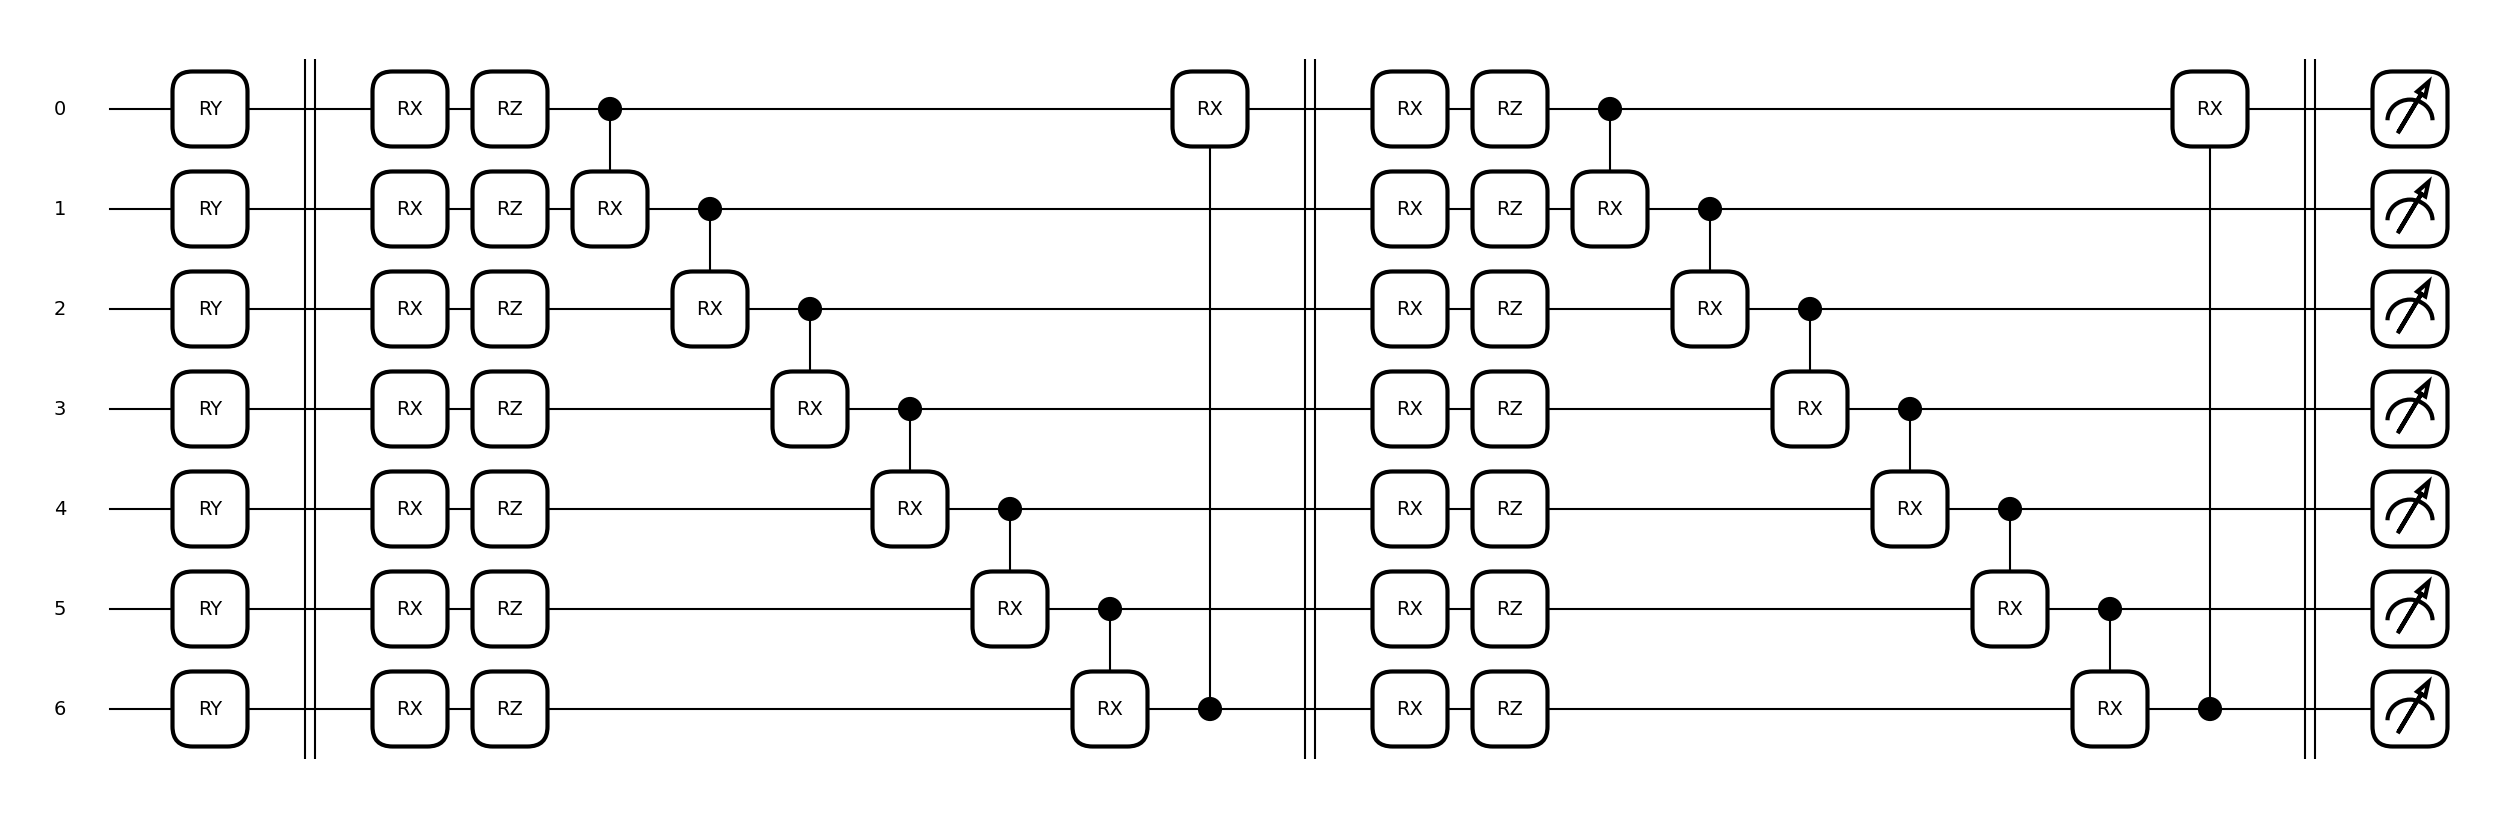

In [22]:
@qml.qnode(device=dev, interface='torch')
def circuit(w):
    noise = torch.randn(num_qubits) * np.pi /2
    weights = w.reshape(depth, 3, num_qubits)
    for i in range(num_qubits):
        qml.RY(noise[i], wires =i)
    qml.Barrier()
    for depth_no in range(depth):
        for params in range(3):
            for i in range(num_qubits):
                if params ==0:
                    qml.RX(weights[depth_no][params][i], wires=i) 
                elif params ==1:
                    qml.RZ(weights[depth_no][params][i], wires=i)
                elif params ==2:
                    qml.CRX(weights[depth_no][params][i], wires=[i, i+1 if i < num_qubits -1 else 0])
        qml.Barrier()
    output = qml.probs(wires=list(range(num_qubits)))
    return output

weight = torch.randn(2 * 7 * 3)
print(qml.draw_mpl(circuit)(weight))

In [56]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.num_params = num_qubits * 3 * depth
        self.params = nn.Parameter(torch.randn(self.num_params))
    
    def forward(self, input):
        x = circuit(self.params, input)
        return torch.tensor(x, dtype=torch.float32)

In [61]:
m = Encoder()
print(m())
num_qubits = 6
batch_size =1


tensor([2.6069e-02, 5.3707e-03, 7.6318e-03, 1.4627e-04, 1.7912e-01, 3.4230e-02,
        1.1228e-01, 1.9624e-02, 6.5981e-02, 6.7516e-03, 2.1586e-02, 5.3110e-04,
        8.2873e-02, 1.0221e-02, 3.9301e-02, 6.4296e-03, 2.9247e-02, 3.7091e-03,
        1.6791e-02, 2.6226e-05, 5.5781e-03, 3.7943e-03, 1.1905e-02, 2.0168e-03,
        7.5139e-03, 1.0313e-03, 7.3278e-03, 1.6189e-04, 1.5512e-02, 3.2777e-03,
        1.3480e-02, 3.8470e-03, 3.2152e-03, 4.4681e-03, 1.1538e-03, 5.5345e-04,
        1.5440e-02, 1.3915e-02, 1.4578e-02, 1.8670e-02, 1.6785e-02, 4.4671e-03,
        1.7754e-02, 5.2605e-04, 3.1092e-02, 6.0352e-03, 2.0464e-02, 6.4481e-03,
        5.4064e-03, 6.4586e-05, 4.9593e-03, 5.1517e-03, 1.7096e-02, 1.5095e-02,
        7.8220e-03, 1.4471e-03, 3.8418e-03, 3.4097e-04, 3.0713e-03, 2.4087e-03,
        3.3357e-03, 5.4179e-03, 3.5220e-03, 2.0924e-03])


/tmp/ipykernel_1804537/1950190619.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x, dtype=torch.float32)


In [28]:
class Encoding_NN(nn.Module):
    def __init__(self):
        super(Encoding_NN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(7, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512), 
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 128),
            nn.Tanh()
            
        )
    def forward(self):
        noise = torch.randn(batch_size, 6, device = device)
        return self.model(noise)

In [33]:
Encoding_NN().to(device)().shape

torch.Size([64, 128])

In [34]:
latent = torch.randn(batch_size, num_qubits).to(device)
latent.shape

torch.Size([64, 7])

In [39]:
import time
from torchvision.utils import save_image

print("Testing phase started...")
num_test_iters = 50

netG.eval()
netD.eval()
array = []
losses = []
in_time = time.time()
lr = 0.01
mid_out = IntermediateLayerGetter(netD, return_layers=return_layers, keep_output=True)
for batch_idx, x in enumerate(dataloader):
    test_loss = None
    anomaly_score = None
    f_G_z = None
    f_x = None

    # Instantiate the encoder once per batch, not per iteration
    # encoder = Encoder().to(device)  # One encoder for every batch
    encoder = Encoding_NN().to(device)
    optimiser_encoder = torch.optim.Adam(encoder.parameters(), lr=0.01)

    # Move input to the device once
    x = x[0].to(device)
    for iter in range(num_test_iters):
        latent = torch.randn(batch_size, num_qubits).to(device)
        optimiser_encoder.zero_grad()

        # Forward pass through the encoder
        latent = encoder().to(device)
        # if iter ==0: print(latent)
        print("enocder output: ", latent.shape)
        generated_images = netG(latent)
        
        # Compute the residual loss
        residual_loss = l2_error(x, generated_images)

        # residual_loss.backward()
        # # Get the intermediate outputs from the discriminator
        f_G_z, model_output = mid_out(generated_images)
        f_x, model_output_1 = mid_out(x)

        f_G_z = f_G_z['intermediate_layer_10']
        f_x = f_x['intermediate_layer_10']

        # # Compute the discriminator loss
        discriminator_loss = l2_error(f_G_z, f_x)

        # # Compute total test loss
        alpha = 0.1
        test_loss = alpha * discriminator_loss + (1 - alpha) * residual_loss
        test_loss.backward()
        losses.append(test_loss.item())
        # Update the encoder
        optimiser_encoder.step()
        # if iter%5==0 and iter > 0: print(iter,": done")
    # print(f'Batch {batch_idx} finished.')
    r+=1
    # Save generated images after processing the batch
    # save_image(torchvision.utils.make_grid(list(zip(x, generated_images))), f"images/batch{batch_idx}.png")
    save_image(x, f'images/qgan/input_image{batch_idx}.png', normalize = True)
    save_image(generated_images, f'images/qgan/batch_{batch_idx}_{r}.png', normalize=True)
    # plot_comp(x, generated_images)
    batch_time = time.time()
    print(f"Batch {batch_idx}, Time taken: {time.time() - in_time}")
    break

out_time = time.time()
print(f"Time taken in minutes: {(out_time - in_time) / 60}")


Testing phase started...
enocder output:  torch.Size([64, 128])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x128 and 64x32768)

In [36]:
import time
from torchvision.utils import save_image

print("Testing phase started...")
num_test_iters = 100

netG.eval()
netD.eval()
array = []
in_time = time.time()

for batch_idx, x in enumerate(test_dataloader):
    test_loss = None
    generated_images = None
    anomaly_score = None
    f_G_z = None
    f_x = None

    # Instantiate the encoder once per batch, not per iteration
    encoder = Encoder().to(device)  # One encoder for every batch
    optimiser_encoder = torch.optim.Adam(encoder.parameters(), lr=0.001, betas=(beta1, 0.999))

    # Move input to the device once
    x = x.to(device)
    if batch_idx==0: print(x.shape)
    for iter in range(num_test_iters):
        latent = torch.randn(batch_size, num_qubits).to(device)
        optimiser_encoder.zero_grad()

        # Forward pass through the encoder
        latent_z = encoder()
        # print("enocder output: ", latent_z)
        generated_images = netG(latent_z.view(1, -1))

        # Compute the residual loss
        residual_loss = l2_error(x, generated_images)

        # Get the intermediate outputs from the discriminator
        mid_out = IntermediateLayerGetter(netD, return_layers=return_layers, keep_output=True)
        f_G_z, model_output = mid_out(generated_images)
        f_x, model_output_1 = mid_out(x)

        f_G_z = f_G_z['intermediate_layer_10']
        f_x = f_x['intermediate_layer_10']

        # Compute the discriminator loss
        discriminator_loss = l2_error(f_G_z, f_x)

        # Compute total test loss
        alpha = 0.1
        test_loss = alpha * torch.mean(discriminator_loss) + (1 - alpha) * torch.mean(residual_loss)
        test_loss.backward()

        # Update the encoder
        optimiser_encoder.step()
        if iter%5==0 and iter > 0: print(iter,": done")
    print(f'Batch {batch_idx} finished.')

    # Save generated images after processing the batch
    # save_image(x, f'generated_images/input_image{batch_idx}.png', normalize = True)
    # save_image(generated_images, f'generated_images/batch_{batch_idx}.png', normalize=True)

    print(f"Batch {batch_idx}, Time taken: {time.time() - in_time}")
    in_time = time.time()

out_time = time.time()
print(f"Time taken in minutes: {(out_time - in_time) / 60}")


Testing phase started...


NameError: name 'Encoder' is not defined